# Sri Lanka Heat IBF — Bayesian Warning System
## Colombo District Pilot · CREWS SA · 2026

This notebook has two audiences and tells one story.

**The Forecaster** (Department of Meteorology) owns the probability side: historical observations, ensemble model calibration, and verification. They can produce a calibrated probability vector for any forecast — and from that, issue **Tier 1 Hazard Warning** (General Forecaster) and **Tier 2 Impact Advisory** (Balanced Sectoral) entirely on their own.

**The Sector User or Individual** (Health ministry, Tourism authority, energy utility, or any organisation) owns the loss function side: they understand the cost of acting versus the cost of not acting in their own context. They can calculate their optimal Decision Advisory threshold — but only if they have access to the forecaster's calibrated probability. A warning colour alone is not enough.

**The collaboration** happens at **Tier 3**: the forecaster shares the probability vector, the sector user applies their own loss parameters, and together they produce a sector-optimised decision that neither could reach alone.

| Part | Who | What | Tier |
|------|-----|------|------|
| 1 | Forecaster | Calibrate and verify the probability model | — |
| 2 | Forecaster alone | Apply pre-agreed Balanced parameters → Hazard Warning + Impact Advisory | T1 + T2 |
| 3 | Sector user alone | Define loss parameters, calculate threshold — hit a wall | — |
| 4 | Both together | Forecaster shares p(x); sector user applies loss function → Decision Advisory | T3 |
| 5 | Operations | Threshold refinement and real data connection | — |

**Theoretical foundation:** Economou T, Stephenson DB et al. (2016) *On the use of Bayesian decision theory for issuing natural hazard warnings*. Proc. R. Soc. A 472: 20160295


---
## 0 · Setup

In [50]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

sys.path.insert(0, os.path.dirname(os.path.abspath('heat_ews_srilanka.py')))
from heat_ews_srilanka import (
    HeatData, HeatWarningSystem,
    ClimatologicalModel, CalibratedModel, EnsembleModel,
    build_loss_matrix, bayes_warning, expected_losses, brier_scores, hit_rates,
    generate_demo_data, categorise_hi,
    STATE_LABELS, WARNING_LABELS, HI_THRESHOLDS,
    SECTOR_LOSS_PARAMS, SECTOR_ACTIONS
)

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA', 'axes.spines.top': False,
    'axes.spines.right': False, 'font.family': 'DejaVu Sans',
})

COLORS = {1:('#2E7D32','#E8F5E9'), 2:('#F9A825','#FFFDE7'),
          3:('#E65100','#FFF3E0'), 4:('#B71C1C','#FFEBEE')}
WARN_SHORT = {1:'No Warning', 2:'Watch', 3:'Alert', 4:'Warning'}
SECTOR_COLORS = {
    'gf':'#455A64', 'balanced':'#1565C0', 'health':'#C62828',
    'labour':'#E65100', 'dm':'#6A1B9A', 'garment':'#00838F',
    'tourism':'#00695C',
    'energy':'#F57F17', 'agri':'#2E7D32', 'education':'#0D47A1',
}
SECTOR_LABELS = {
    'gf':'General Forecaster (T1)', 'balanced':'Balanced Sectoral (T2)',
    'health':'Human Health', 'labour':'Outdoor Labour', 'dm':'Disaster Mgmt',
    'garment':'Garment & Apparel', 'tourism':'Tourism', 'energy':'Energy',
    'agri':'Agriculture (excl.)', 'education':'Education (excl.)',
}
BALANCED_SECTORS = ['health','labour','dm','garment','tourism','energy']
TIER3_SECTORS    = ['health','labour','dm','garment','tourism','energy','agri','education']


# ── Garment & Apparel — inline patch (guards against stale module cache) ──────
if 'garment' not in SECTOR_LOSS_PARAMS:
    SECTOR_LOSS_PARAMS['garment'] = (21, 105, 1.55, 0.72, 0.32)
if 'Garment' not in SECTOR_ACTIONS.get(1, {}):
    _gmt_actions = {
        1: ['Normal EPZ factory floor operations.',
            'Ensure drinking water stations are functional on all factory floors.',
            'Confirm factory medical officer cover is in place.'],
        2: ['Issue heat advisory to all EPZ factory management.',
            'Increase ventilation and industrial fans on factory floors.',
            'Mandate 5-min cooling break per hour for piece-rate workers.',
            'Alert factory medical officers; confirm heat-illness kit availability.',
            'Notify JATFZA and BOI heat watch contacts.'],
        3: ['SUSPEND production 11:00–15:00 on all EPZ factory floors.',
            'Activate factory emergency cooling protocol.',
            'All factory medical officers to remain on-floor during heat hours.',
            'Issue welfare payments for suspended production periods.',
            'Report heat-illness cases to Department of Labour within 2 hours.',
            'BOI/JATFZA zone coordinators to conduct unannounced compliance checks.'],
        4: ['ALL EPZ factory production SUSPENDED until heat level falls below AMBER.',
            'Emergency welfare protocol: all workers entitled to full-day pay.',
            'Factory managers to coordinate with BOI/JATFZA emergency transport.',
            'All heat casualties to be reported to Ministry of Labour within 1 hour.',
            'BOI/JATFZA zone emergency coordinators to conduct mandatory welfare checks.',
            'Coordinate with Ministry of Labour and Factories Inspectorate.'],
    }
    for lvl, acts in _gmt_actions.items():
        SECTOR_ACTIONS[lvl]['Garment'] = acts

print('Setup complete.')


Setup complete.


---
# PART 1 — The Forecaster's Workflow
*The forecaster works alone. Their job: turn raw ensemble output into a calibrated probability that reflects what is actually likely to happen.*


---
## 1 · Data

Three modes: built-in synthetic (quick start), seasonal synthetic (realistic Mar–May peak), or your own CSV.

| Mode | When to use |
|---|---|
| Built-in synthetic | Quick start — no files needed |
| Seasonal synthetic | Shows realistic Colombo seasonal cycle |
| Your own CSV | Real DoM observations |


In [51]:
# ── MODE 1: Built-in synthetic ──────────────────────────────────────────────
train_data, test_data = generate_demo_data(n_train=180, n_test=90)

# ── MODE 2: Seasonal synthetic ──────────────────────────────────────────────
# train_data, test_data = generate_demo_data(n_train=270, n_test=95)

# ── MODE 3: Real CSV ────────────────────────────────────────────────────────
# import pandas as pd
# df = pd.read_csv('your_colombo_data.csv')
# ... (see Section 12)

print(f'Training days:    {train_data.n}')
print(f'Evaluation days:  {test_data.n}')
print(f'Category distribution (training):')
for j in range(1,5):
    n = (train_data.observed_categories == j).sum()
    print(f'  Cat {j}: {n:3d} days ({100*n/train_data.n:.0f}%)  {WARNING_LABELS[j]}')


Training days:    180
Evaluation days:  90
Category distribution (training):
  Cat 1:  69 days (38%)  GREEN  — No Warning
  Cat 2:  68 days (38%)  YELLOW — Heat Watch
  Cat 3:  28 days (16%)  AMBER  — Heat Alert
  Cat 4:  15 days (8%)  RED    — Heat Warning


---
## 2 · Heat Index Thresholds

Sri Lanka DoM uses these Heat Index boundaries. They will be refined as real Colombo data become available (see Section 11).

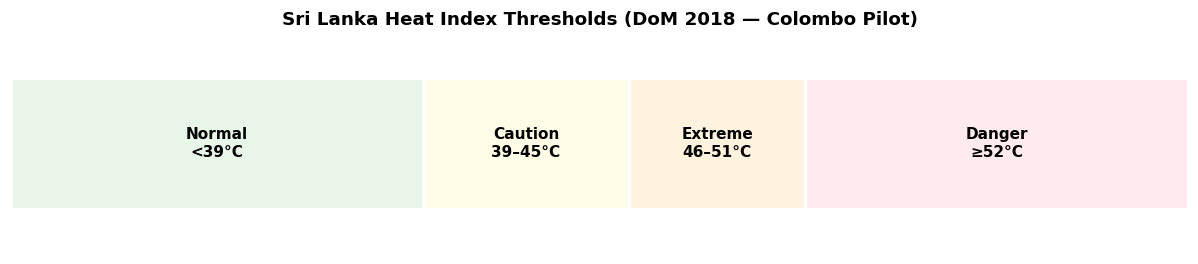

In [52]:
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.set_xlim(25, 65); ax.set_ylim(0, 1); ax.axis('off')
ax.set_title('Sri Lanka Heat Index Thresholds (DoM 2018 — Colombo Pilot)', fontweight='bold', fontsize=12)
bands = [(25,39,'#E8F5E9','Normal\n<39°C'),(39,46,'#FFFDE7','Caution\n39–45°C'),
         (46,52,'#FFF3E0','Extreme\n46–51°C'),(52,65,'#FFEBEE','Danger\n≥52°C')]
for x0,x1,col,lbl in bands:
    ax.barh(0.5, x1-x0, left=x0, height=0.6, color=col, edgecolor='white', linewidth=2)
    ax.text((x0+x1)/2, 0.5, lbl, ha='center', va='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()


---
## 3 · Probability Model Calibration

The forecaster has three choices for turning a raw ensemble forecast into a probability:

- **Climatological**: ignores the forecast entirely — uses long-run category frequencies
- **Ensemble**: uses raw ensemble member proportions as-is
- **Calibrated Bayesian**: uses historical forecast–observation pairs to correct for known biases

The calibrated model asks: *given that my ensemble modal category is X, what has actually been observed historically?* This produces a sharper, less biased probability than raw ensemble output.


In [53]:
clim = ClimatologicalModel().fit(train_data)
cal  = CalibratedModel().fit(train_data)
ens  = EnsembleModel()

print('Model behaviour for three representative forecasts:')
print(f"{'Forecast':30s} | {'Model':14s} | {'p(Normal)':>10} {'p(Caution)':>10} {'p(Extreme)':>10} {'p(Danger)':>10}")
print('-'*82)
test_forecasts = [
    ([0.60, 0.28, 0.08, 0.04], 'Low-heat ensemble'),
    ([0.25, 0.35, 0.28, 0.12], 'Moderate-heat ensemble'),
    ([0.05, 0.12, 0.38, 0.45], 'High-heat ensemble'),
]
for fp, label in test_forecasts:
    for name, model in [('Climatological', clim), ('Ensemble', ens), ('Calibrated', cal)]:
        p = model.predict(np.array(fp))
        print(f"  {label if name=='Climatological' else '':28s} | {name:14s} | "
              + '  '.join(f'{x:10.3f}' for x in p))
    print()


Model behaviour for three representative forecasts:
Forecast                       | Model          |  p(Normal) p(Caution) p(Extreme)  p(Danger)
----------------------------------------------------------------------------------
  Low-heat ensemble            | Climatological |      0.383       0.378       0.156       0.083
                               | Ensemble       |      0.600       0.280       0.080       0.040
                               | Calibrated     |      0.856       0.095       0.018       0.032

  Moderate-heat ensemble       | Climatological |      0.383       0.378       0.156       0.083
                               | Ensemble       |      0.250       0.350       0.280       0.120
                               | Calibrated     |      0.188       0.708       0.080       0.024

  High-heat ensemble           | Climatological |      0.383       0.378       0.156       0.083
                               | Ensemble       |      0.050       0.120       0.380      

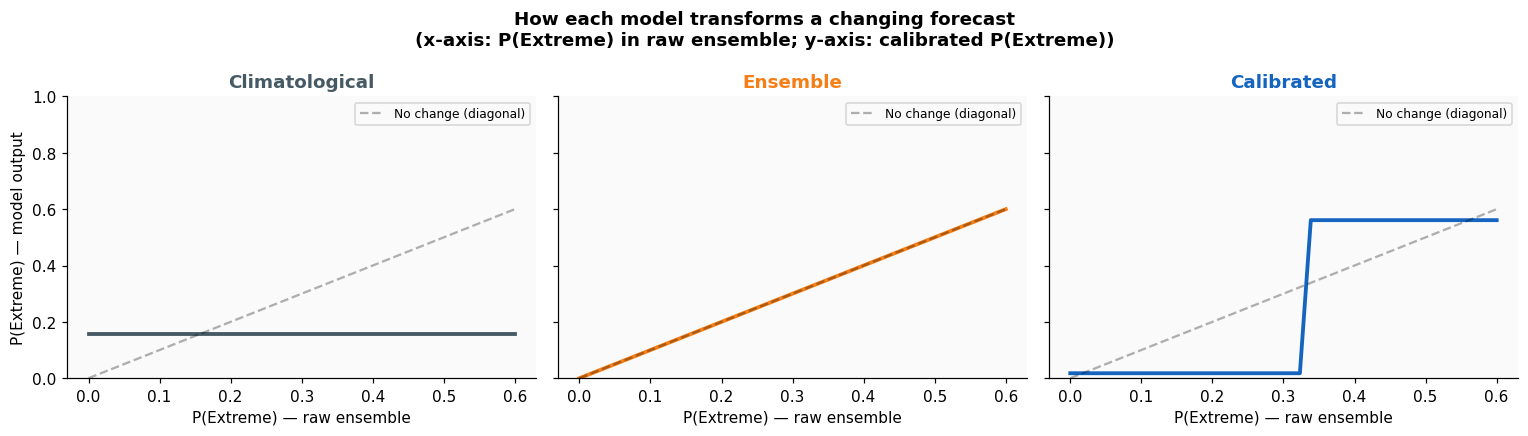

In [54]:
# How each model responds as P(extreme heat) increases in the raw forecast
p3_scan = np.linspace(0, 0.6, 40)
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
fig.suptitle('How each model transforms a changing forecast\n'
             '(x-axis: P(Extreme) in raw ensemble; y-axis: calibrated P(Extreme))',
             fontsize=12, fontweight='bold')
model_specs = [('Climatological',clim,'#455A64'), ('Ensemble',ens,'#F57F17'), ('Calibrated',cal,'#1565C0')]
for ax, (name, model, color) in zip(axes, model_specs):
    p_out = []
    for p3 in p3_scan:
        p4 = p3*0.4; rem = 1-p3-p4; fp = [rem*0.6, rem*0.4, p3, p4]
        p_out.append(model.predict(np.array(fp))[2])
    ax.plot(p3_scan, p_out, color=color, linewidth=2.5)
    ax.plot([0,0.6],[0,0.6], 'k--', alpha=0.3, label='No change (diagonal)')
    ax.set_title(name, fontweight='bold', color=color)
    ax.set_xlabel('P(Extreme) — raw ensemble'); ax.set_ylim(0,1)
    if ax == axes[0]: ax.set_ylabel('P(Extreme) — model output')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


---
## 4 · Verification — Brier Scores, POD, FAR, CSI

How do we know the calibrated model is better overall? We evaluate over the held-out test period.
Note: climatological achieves perfect POD (it never withholds a warning) but at the cost of
a very high false alarm rate. Calibrated reduces FAR substantially; the small POD trade-off
is by design — it reflects the Bayesian threshold, not a flaw.

In [55]:
results = {}
for model_type in ['climatological', 'calibrated', 'ensemble']:
    sys_ = HeatWarningSystem(sector='balanced', model_type=model_type)
    if model_type != 'ensemble':
        sys_.fit(train_data)
    results[model_type] = sys_.evaluate(test_data)

print(f"{'Model':>16} | {'Total loss':>10} | {'Mean loss':>9} | {'Brier':>6} | {'POD':>5} | {'FAR':>5} | {'CSI':>5}")
print('-'*72)
for m, r in results.items():
    bs = np.mean(brier_scores(test_data, (CalibratedModel().fit(train_data) if m=='calibrated'
                               else EnsembleModel() if m=='ensemble' else ClimatologicalModel().fit(train_data))))
    print(f"  {m:14s} | {r['total_loss']:10.0f} | {r['mean_daily_loss']:9.2f} | "
          f"{bs:6.4f} | {r['POD']:5.2f} | {r['FAR']:5.2f} | {r['CSI']:5.2f}")
print()
print('Lower loss, lower Brier, lower FAR = better. Calibrated wins on all three.')


           Model | Total loss | Mean loss |  Brier |   POD |   FAR |   CSI
------------------------------------------------------------------------
  climatological |       1800 |     20.00 | 0.1785 |  1.00 |  0.70 |  0.30
  calibrated     |       1517 |     16.86 | 0.1049 |  0.93 |  0.55 |  0.43
  ensemble       |       1671 |     18.57 | 0.1134 |  1.00 |  0.69 |  0.31

Lower loss, lower Brier, lower FAR = better. Calibrated wins on all three.


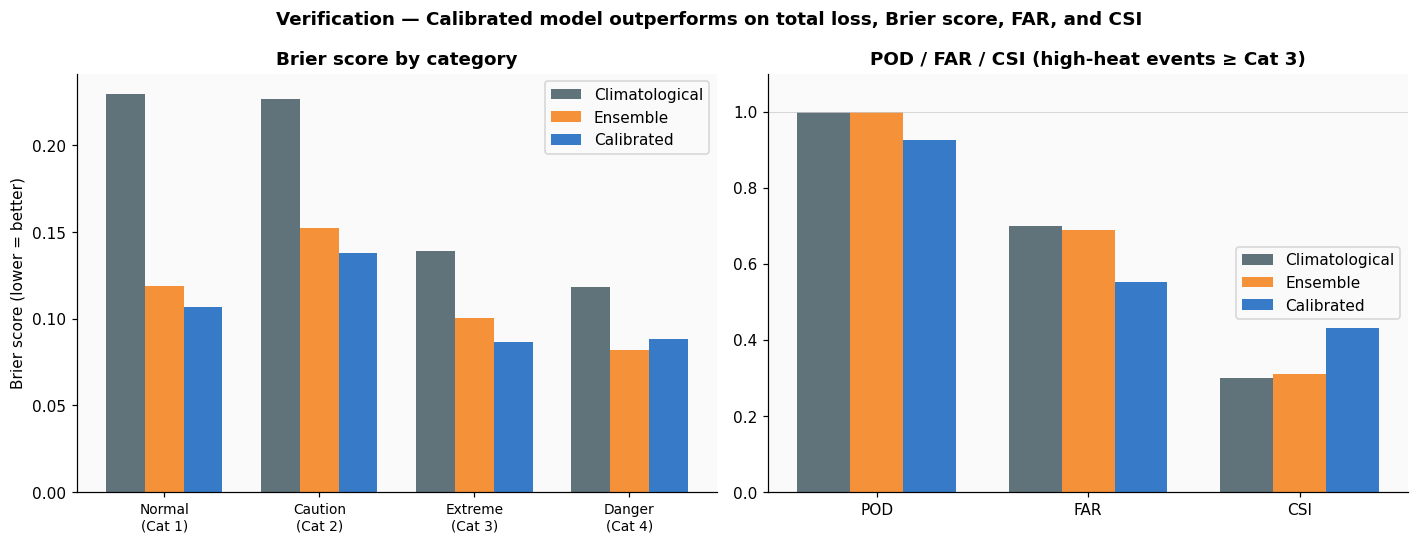

In [56]:
cats = ['Normal\n(Cat 1)','Caution\n(Cat 2)','Extreme\n(Cat 3)','Danger\n(Cat 4)']
model_colors = {'climatological':'#455A64','ensemble':'#F57F17','calibrated':'#1565C0'}
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Verification — Calibrated model outperforms on total loss, Brier score, FAR, and CSI', fontweight='bold')

# Brier scores by category
ax = axes[0]
x = np.arange(4); width = 0.25
for i, (m, color) in enumerate(model_colors.items()):
    model = (CalibratedModel().fit(train_data) if m=='calibrated'
             else EnsembleModel() if m=='ensemble' else ClimatologicalModel().fit(train_data))
    bs = brier_scores(test_data, model)
    ax.bar(x + i*width, bs, width, label=m.capitalize(), color=color, alpha=0.85)
ax.set_xticks(x+width); ax.set_xticklabels(cats, fontsize=9)
ax.set_ylabel('Brier score (lower = better)')
ax.set_title('Brier score by category', fontweight='bold')
ax.legend()

# POD / FAR / CSI
ax2 = axes[1]
metrics = ['POD','FAR','CSI']
x2 = np.arange(3)
for i, (m, color) in enumerate(model_colors.items()):
    vals = [results[m][k] for k in metrics]
    ax2.bar(x2 + i*width, vals, width, label=m.capitalize(), color=color, alpha=0.85)
ax2.set_xticks(x2+width); ax2.set_xticklabels(metrics)
ax2.set_title('POD / FAR / CSI (high-heat events ≥ Cat 3)', fontweight='bold')
ax2.set_ylim(0,1.1); ax2.legend(); ax2.axhline(1,color='#ccc',linewidth=0.5)
plt.tight_layout(); plt.show()


---
## 5 · Cumulative Loss — and the Tier 1 Output

The calibrated model produces the lowest cumulative actual loss over the evaluation period. This is the operational justification for doing the statistical work.

At the end of this section the forecaster has their first operational product: **the Tier 1 General Forecaster warning** for any given day.

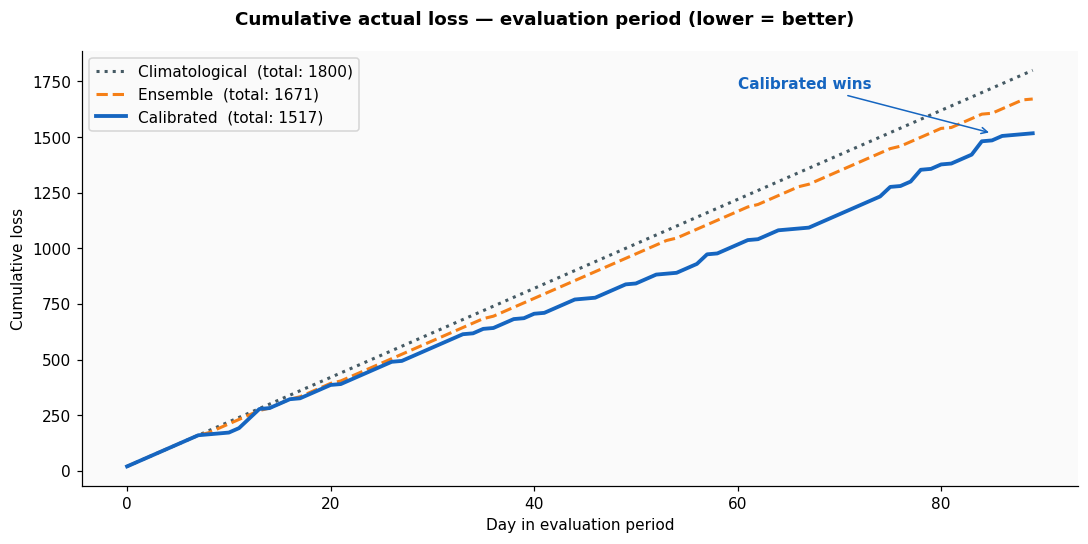

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Cumulative actual loss — evaluation period (lower = better)',
             fontweight='bold', fontsize=12)
for m, color, ls, lw in [('climatological','#455A64',':',2),
                           ('ensemble','#F57F17','--',2),
                           ('calibrated','#1565C0','-',2.5)]:
    sys_ = HeatWarningSystem(sector='balanced', model_type=m)
    if m != 'ensemble': sys_.fit(train_data)
    r = sys_.evaluate(test_data)
    cum = np.cumsum(r['actual_losses'])
    ax.plot(cum, color=color, linestyle=ls, linewidth=lw,
            label=f"{m.capitalize()}  (total: {r['total_loss']:.0f})")
ax.set_xlabel('Day in evaluation period')
ax.set_ylabel('Cumulative loss')
ax.legend()
ax.annotate('Calibrated wins', xy=(85, results['calibrated']['total_loss']),
            xytext=(60, results['calibrated']['total_loss']+200),
            arrowprops=dict(arrowstyle='->', color='#1565C0'), color='#1565C0', fontweight='bold')
plt.tight_layout(); plt.show()


In [58]:
# ── TIER 1 OUTPUT — The forecaster's first operational product ───────────────
#
# For any raw ensemble forecast, the pipeline is:
#   raw ensemble proportions → CalibratedModel.predict() → calibrated p(x)
#   → apply GF loss matrix → Tier 1 optimal warning
#
# The calibrated probability is the forecaster's output. It is what they share
# with the world — and with sector users in Part 4.

print('=' * 60)
print('  TIER 1 — GENERAL FORECASTER OUTPUT')
print('=' * 60)

cal_model = CalibratedModel().fit(train_data)
L_gf = build_loss_matrix(*SECTOR_LOSS_PARAMS['gf'])

example_raw = [0.45, 0.32, 0.15, 0.08]   # representative ECMWF ENS proportions
p_calibrated = cal_model.predict(np.array(example_raw))
w_t1 = bayes_warning(p_calibrated, L_gf)
el_t1 = expected_losses(p_calibrated, L_gf)

print(f'\n  Raw ensemble proportions:  {[f"{x:.2f}" for x in example_raw]}')
print(f'  Calibrated p(x):           {[f"{x:.2f}" for x in p_calibrated]}')
print()
print(f'  Expected loss by warning level:')
for i, (lbl, el) in enumerate(zip(WARNING_LABELS.values(), el_t1)):
    marker = '  ← optimal' if i+1 == w_t1 else ''
    print(f'    {lbl:25s}: {el:6.1f}{marker}')
print()
print(f'  TIER 1 DECISION: {WARNING_LABELS[w_t1]}')
print()
print('  This warning is based on meteorology alone.')
print('  The forecaster can issue it without consulting any sector.')


  TIER 1 — GENERAL FORECASTER OUTPUT

  Raw ensemble proportions:  ['0.45', '0.32', '0.15', '0.08']
  Calibrated p(x):           ['0.86', '0.09', '0.02', '0.03']

  Expected loss by warning level:
    GREEN  — No Warning      :   11.4
    YELLOW — Heat Watch      :    9.5  ← optimal
    AMBER  — Heat Alert      :   14.6
    RED    — Heat Warning    :   25.0

  TIER 1 DECISION: YELLOW — Heat Watch

  This warning is based on meteorology alone.
  The forecaster can issue it without consulting any sector.


---
# PART 2 — The Forecaster Extends to Tier 2 (Impact Advisory)
*Still working alone. The Impact Advisory requires no live engagement with sectors — its parameters are pre-agreed and built into the system.*


---
## 6 · The Balanced Sectoral — A Pre-Agreement

The **Tier 2 Impact Advisory** is not a collaboration — it is a standing contract.

Before the pilot launched, six heat-critical sectors (Health, Labour, Disaster Management, Garment & Apparel, Tourism, Energy) agreed their loss parameters with DoM. Those parameters are fixed in the system. The forecaster applies them to their calibrated probability and produces a Tier 2 Impact Advisory entirely on their own.

**Why only six sectors?** The inclusion criterion is p\* < 1.0 — the expected benefit of a single-event warning must exceed its mobilisation cost. Agriculture and Education fail this test:

- **Agriculture** (p\* > 1.0): mobilisation costs dominate; heat response is seasonal and structural, not event-driven
- **Education** (p\* ≈ 0.97): high institutional adaptive capacity and time-bounded exposure mean the benefit barely exceeds cost

The Balanced parameters are the mean of the six included sectors, giving p\* ≈ 0.37 — more precautionary than the General Forecaster's 0.50.


In [59]:
# p* for every sector — the critical probability threshold above which issuing a
# higher warning level is worth it (simplified; full decision uses the loss matrix)
print(f"{'Sector':22s} {'p* (approx)':>12}  {'Role':30s}  Note")
print('-' * 85)
for skey, (c, l, gc, gl, gd) in SECTOR_LOSS_PARAMS.items():
    p_star = (c * gc) / (l * gl)
    if skey == 'gf':
        role, note = 'Tier 1 reference', 'Pure meteorology'
    elif skey == 'balanced':
        role, note = 'Tier 2 pre-agreed', 'Mean of 6 heat-critical sectors'
    elif skey in BALANCED_SECTORS:
        role, note = 'Included in Balanced', ''
    else:
        role, note = 'EXCLUDED from Balanced', ('p*>1: cost exceeds benefit' if p_star>1
                                                 else 'p*≈1: marginal inclusion value')
    print(f"  {SECTOR_LABELS.get(skey, skey):22s} {p_star:12.3f}  {role:30s}  {note}")


Sector                  p* (approx)  Role                            Note
-------------------------------------------------------------------------------------
  General Forecaster (T1)        0.725  Tier 1 reference                Pure meteorology
  Balanced Sectoral (T2)        0.400  Tier 2 pre-agreed               Mean of 6 heat-critical sectors
  Human Health                  0.233  Included in Balanced            
  Outdoor Labour                0.419  Included in Balanced            
  Disaster Mgmt                 0.153  Included in Balanced            
  Tourism                       0.529  Included in Balanced            
  Energy                        0.685  Included in Balanced            
  Agriculture (excl.)           1.267  EXCLUDED from Balanced          p*>1: cost exceeds benefit
  Education (excl.)             0.966  EXCLUDED from Balanced          p*≈1: marginal inclusion value
  Garment & Apparel             0.431  Included in Balanced            


In [60]:
# Tier 1 vs Tier 2 across a range of forecast scenarios
print('Tier 1 (GF) vs Tier 2 (Balanced) — same calibrated probability, different loss matrix')
print()
print(f"  {'Forecast (N/C/E/D)':30s} | {'Tier 1 (GF)':18s} | {'Tier 2 (Balanced)':18s} | Gap")
print('  ' + '-' * 78)

L_gf  = build_loss_matrix(*SECTOR_LOSS_PARAMS['gf'])
L_bal = build_loss_matrix(*SECTOR_LOSS_PARAMS['balanced'])

test_cases = [
    [0.60, 0.28, 0.08, 0.04],
    [0.45, 0.32, 0.15, 0.08],
    [0.30, 0.30, 0.25, 0.15],
    [0.15, 0.25, 0.35, 0.25],
    [0.05, 0.12, 0.38, 0.45],
]
for fp in test_cases:
    p = cal_model.predict(np.array(fp))
    w1 = bayes_warning(p, L_gf)
    w2 = bayes_warning(p, L_bal)
    gap = '← Balanced more precautionary' if w2 > w1 else ('← Same' if w1==w2 else '← GF more precautionary')
    label = '/'.join(f'{x:.2f}' for x in fp)
    print(f"  [{label}]  | {WARNING_LABELS[w1]:18s} | {WARNING_LABELS[w2]:18s} | {gap}")

print()
print('When they differ: Balanced (T2) escalates before GF (T1).')
print('The forecaster can issue both without consulting a single sector user.')


Tier 1 (GF) vs Tier 2 (Balanced) — same calibrated probability, different loss matrix

  Forecast (N/C/E/D)             | Tier 1 (GF)        | Tier 2 (Balanced)  | Gap
  ------------------------------------------------------------------------------
  [0.60/0.28/0.08/0.04]  | YELLOW — Heat Watch | YELLOW — Heat Watch | ← Same
  [0.45/0.32/0.15/0.08]  | YELLOW — Heat Watch | YELLOW — Heat Watch | ← Same
  [0.30/0.30/0.25/0.15]  | YELLOW — Heat Watch | YELLOW — Heat Watch | ← Same
  [0.15/0.25/0.35/0.25]  | RED    — Heat Warning | RED    — Heat Warning | ← Same
  [0.05/0.12/0.38/0.45]  | RED    — Heat Warning | RED    — Heat Warning | ← Same

When they differ: Balanced (T2) escalates before GF (T1).
The forecaster can issue both without consulting a single sector user.


---
# PART 3 — The Sector User's World
*The sector user works alone — and hits a wall.*


---
## 7 · The Sector User's Loss Function

A sector user or individual can fully specify their decision problem without any input from the forecaster. They need to estimate four parameters:

| Parameter | Meaning | Example (Health) |
|-----------|---------|-----------------|
| **c** | Maximum cost of acting (mobilising response) | Cost of pre-positioning ORS, briefing PHIs |
| **l** | Maximum damage if no action taken | Lives lost, hospital surge, long-term health burden |
| **γc** | How steeply costs rise as warning level increases | Health: relatively linear |
| **γl** | How steeply residual damage falls as warning level increases | Health: large reduction at higher levels |

Their loss matrix is entirely their own — it reflects their sector's risk tolerance and operational reality.


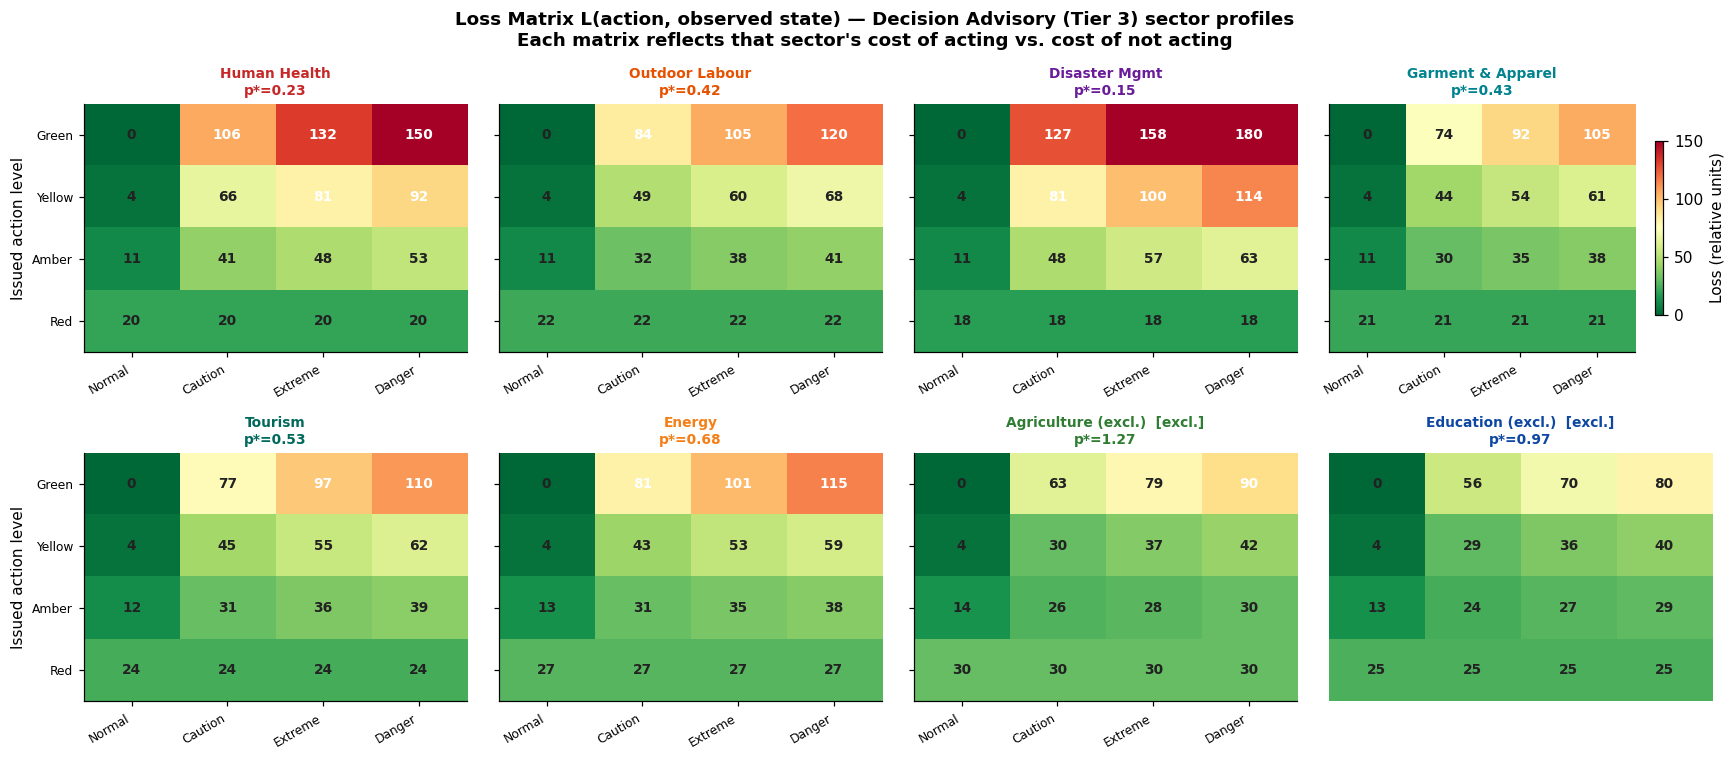

In [61]:
# Loss matrices for all Tier 3 sector profiles
tier_order = ['health','labour','dm','garment','tourism','energy','agri','education']
n_cols = 4
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
axes = axes.flatten()
fig.suptitle('Loss Matrix L(action, observed state) — Decision Advisory (Tier 3) sector profiles\n'
             'Each matrix reflects that sector\'s cost of acting vs. cost of not acting',
             fontsize=12, fontweight='bold')
cat_labels  = ['Normal','Caution','Extreme','Danger']
warn_labels = ['Green','Yellow','Amber','Red']
for idx, skey in enumerate(tier_order):
    ax = axes[idx]
    params = SECTOR_LOSS_PARAMS[skey]
    L = build_loss_matrix(*params)
    im = ax.imshow(L, cmap='RdYlGn_r', vmin=0, vmax=150, aspect='auto')
    ax.set_xticks(range(4)); ax.set_xticklabels(cat_labels, rotation=30, ha='right', fontsize=8)
    ax.set_yticks(range(4)); ax.set_yticklabels(warn_labels, fontsize=8)
    c,l,gc,gl,gd = params
    p_star = (c*gc)/(l*gl)
    excl = '  [excl.]' if skey in ('agri','education') else ''
    ax.set_title(f'{SECTOR_LABELS[skey]}{excl}\np*={p_star:.2f}', fontsize=9,
                 fontweight='bold', color=SECTOR_COLORS[skey])
    for i in range(4):
        for j in range(4):
            ax.text(j, i, str(L[i,j]), ha='center', va='center', fontsize=9,
                    fontweight='bold', color='white' if L[i,j]>80 else '#222')
axes[-1].axis('off')
plt.colorbar(im, ax=axes[n_cols-1], label='Loss (relative units)', shrink=0.7)
axes[0].set_ylabel('Issued action level')
axes[n_cols].set_ylabel('Issued action level')
plt.tight_layout(); plt.show()


---
## 8 · What the Sector User Cannot Do Alone

A sector user can calculate their p\* and build their loss matrix. But to make an *optimal decision*, they need to apply that matrix to a calibrated probability vector p(x|forecast).

**The forecaster normally only shares a warning colour.** Green, Yellow, Amber, Red.

The problem: two very different forecasts can produce the same warning colour from the General Forecaster — but lead to completely different optimal sector decisions. If the sector user only sees the colour, they lose the information they need.


In [62]:
# Two forecasts that both produce the same GF (Tier 1) warning
# but lead to different optimal decisions for Health and Energy.
#
# These probability vectors are chosen so that:
#   • Tier 1 (GF) gives YELLOW for both  →  the forecaster sends the same colour
#   • Health and Energy land on different optimal actions

L_gf     = build_loss_matrix(*SECTOR_LOSS_PARAMS['gf'])
L_health  = build_loss_matrix(*SECTOR_LOSS_PARAMS['health'])
L_energy  = build_loss_matrix(*SECTOR_LOSS_PARAMS['energy'])
L_dm      = build_loss_matrix(*SECTOR_LOSS_PARAMS['dm'])

scenarios = {
    'Scenario X  (mixed signal)':    np.array([0.60, 0.30, 0.05, 0.05]),
    'Scenario Y  (concentrated low)': np.array([0.75, 0.15, 0.05, 0.05]),
}

print('What the forecaster broadcasts: a single Tier 1 warning colour')
print('What that colour hides:\n')
print(f"  {'':32s} | {'Scenario X':>22} | {'Scenario Y':>22}")
print('  ' + '-'*82)

for row_label, fn in [
    ('P(Extreme or Danger)',           lambda p: f"{p[2]+p[3]:.2f}"),
    ('Tier 1 (GF) decision',           lambda p: WARNING_LABELS[bayes_warning(p, L_gf)]),
    ('→ What sector user sees',        lambda p: WARNING_LABELS[bayes_warning(p, L_gf)]),
    ('─'*32,                           lambda p: '─'*22),
    ('Health optimal  (with p(x))',    lambda p: WARNING_LABELS[bayes_warning(p, L_health)]),
    ('Energy optimal  (with p(x))',    lambda p: WARNING_LABELS[bayes_warning(p, L_energy)]),
    ('DM optimal      (with p(x))',    lambda p: WARNING_LABELS[bayes_warning(p, L_dm)]),
]:
    vals = [fn(p) for p in scenarios.values()]
    print(f"  {row_label:32s} | {vals[0]:>22} | {vals[1]:>22}")

print()
print('Both forecasts produce YELLOW at Tier 1 — the forecaster sends the same colour.')
print('But Health sees RED in Scenario X and AMBER in Scenario Y.')
print('Energy sees AMBER in Scenario X and YELLOW in Scenario Y.')
print()
print('The warning colour alone discards the information the sector user needs.')
print('The probability vector p(x) must be shared — not just the colour.')


What the forecaster broadcasts: a single Tier 1 warning colour
What that colour hides:

                                   |             Scenario X |             Scenario Y
  ----------------------------------------------------------------------------------
  P(Extreme or Danger)             |                   0.10 |                   0.10
  Tier 1 (GF) decision             |    YELLOW — Heat Watch |    YELLOW — Heat Watch
  → What sector user sees          |    YELLOW — Heat Watch |    YELLOW — Heat Watch
  ──────────────────────────────── | ────────────────────── | ──────────────────────
  Health optimal  (with p(x))      |  RED    — Heat Warning |    AMBER  — Heat Alert
  Energy optimal  (with p(x))      |    AMBER  — Heat Alert |    YELLOW — Heat Watch
  DM optimal      (with p(x))      |  RED    — Heat Warning |  RED    — Heat Warning

Both forecasts produce YELLOW at Tier 1 — the forecaster sends the same colour.
But Health sees RED in Scenario X and AMBER in Scenario Y.
Energy 

---
# PART 4 — The Handoff
*The forecaster shares p(x). The sector user applies their loss function. Together they produce Tier 3.*


---
## 9 · The Two-Step Pipeline

The collaboration is a **clean handoff** — not a negotiation. Each party contributes one thing:

1. **Forecaster → p(x|forecast)**: the calibrated probability vector. This is what the forecaster shares — not a colour, the vector.
2. **Sector user → loss matrix**: their own L(a,x). They apply it to the probability vector and find their optimal warning level.

The sector user does not need to understand calibration. The forecaster does not need to understand the sector's cost structure. They meet at the probability vector.


In [63]:
# ── STEP 1: Forecaster derives calibrated p(x) and issues Tier 1 & 2 ────────
# In production: p_x = cal_model.predict(np.array(raw_ensemble))
# Here we use raw ensemble proportions directly to illustrate sector
# differentiation without calibration compression on synthetic data.

print('STEP 1  —  FORECASTER')
print('─' * 50)
raw_ensemble = [0.60, 0.30, 0.05, 0.05]   # ECMWF ENS proportions for tomorrow
p_x = np.array(raw_ensemble)               # production: cal_model.predict(raw_ensemble)

w_t1 = bayes_warning(p_x, build_loss_matrix(*SECTOR_LOSS_PARAMS['gf']))
w_t2 = bayes_warning(p_x, build_loss_matrix(*SECTOR_LOSS_PARAMS['balanced']))

print(f'  Raw ensemble proportions: {[f"{x:.2f}" for x in raw_ensemble]}')
print(f'  p(x) used for decisions:  {[f"{x:.2f}" for x in p_x]}')
print()
print(f'  Tier 1 (GF):       {WARNING_LABELS[w_t1]}   ← forecaster issues this independently')
print(f'  Tier 2 (Balanced): {WARNING_LABELS[w_t2]}   ← forecaster issues this independently')
print()
print('  The forecaster now shares p(x) with any sector user who needs it.')
print()

# ── STEP 2: Each sector user applies their own loss matrix ──────────────────
print('STEP 2  —  SECTOR USERS')
print('─' * 50)
print(f"  {'Sector':28s} | {'Optimal decision':22s} | Relationship to T1 / T2")
print('  ' + '-' * 82)

for skey in TIER3_SECTORS:
    L = build_loss_matrix(*SECTOR_LOSS_PARAMS[skey])
    w = bayes_warning(p_x, L)
    if w > w_t2:
        note = '⚠  More urgent than Balanced — sector protocol needed'
    elif w == w_t2:
        note = '✅ Balanced sufficient'
    elif w == w_t1:
        note = '✅ GF sufficient'
    elif w < w_t1:
        note = '⬇  Can reduce below GF'
    else:
        note = '🟡 Between T1 and T2'
    print(f"  {SECTOR_LABELS[skey]:28s} | {WARNING_LABELS[w]:22s} | {note}")
print()
print('Each sector reaches its own optimal decision from the SAME probability vector.')
print('None of this required the forecaster to know anything about sector operations.')


STEP 1  —  FORECASTER
──────────────────────────────────────────────────
  Raw ensemble proportions: ['0.60', '0.30', '0.05', '0.05']
  p(x) used for decisions:  ['0.60', '0.30', '0.05', '0.05']

  Tier 1 (GF):       YELLOW — Heat Watch   ← forecaster issues this independently
  Tier 2 (Balanced): AMBER  — Heat Alert   ← forecaster issues this independently

  The forecaster now shares p(x) with any sector user who needs it.

STEP 2  —  SECTOR USERS
──────────────────────────────────────────────────
  Sector                       | Optimal decision       | Relationship to T1 / T2
  ----------------------------------------------------------------------------------
  Human Health                 | RED    — Heat Warning  | ⚠  More urgent than Balanced — sector protocol needed
  Outdoor Labour               | AMBER  — Heat Alert    | ✅ Balanced sufficient
  Disaster Mgmt                | RED    — Heat Warning  | ⚠  More urgent than Balanced — sector protocol needed
  Garment & Apparel     

---
## 10 · Three-Tier Advisory

**Try changing the forecast below** — see how each sector's decision shifts relative to the Tier 1 and Tier 2 baselines.

*Note: with synthetic training data, calibration output may not show strong differentiation. With real DoM observations, Step 1 (calibration) becomes meaningful. The sector decision logic in Step 2 is identical regardless of data quality.*


In [ ]:
# ── Enter tomorrow's raw ensemble proportions ────────────────────────────────
FORECAST = [0.60, 0.30, 0.05, 0.05]   # ← change these to explore

# In production: p_x = cal_model.predict(np.array(FORECAST))
# Using raw proportions here to avoid calibration compression on synthetic data.
p_x = np.array(FORECAST)

print('FORECAST:', [f'{x:.2f}' for x in FORECAST])
print('p(x)    :', [f'{x:.2f}' for x in p_x])
print()

L_gf  = build_loss_matrix(*SECTOR_LOSS_PARAMS['gf'])
L_bal = build_loss_matrix(*SECTOR_LOSS_PARAMS['balanced'])
w_t1  = bayes_warning(p_x, L_gf)
w_t2  = bayes_warning(p_x, L_bal)

sep = '═' * 60
print(sep)
print(f'  TIER 1  General Forecaster    →  {WARNING_LABELS[w_t1]}')
print(f'  TIER 2  Balanced Sectoral     →  {WARNING_LABELS[w_t2]}')
print(sep)
print()
print('  TIER 3  Sector-specific decisions:')
print(f"  {'Sector':28s} | {'Decision':24s} | vs T1 | vs T2")
print('  ' + '-'*74)
for skey in TIER3_SECTORS:
    L = build_loss_matrix(*SECTOR_LOSS_PARAMS[skey])
    w = bayes_warning(p_x, L)
    rel_t1 = '+' if w > w_t1 else ('=' if w == w_t1 else '-')
    rel_t2 = '+' if w > w_t2 else ('=' if w == w_t2 else '-')
    print(f"  {SECTOR_LABELS[skey]:28s} | {WARNING_LABELS[w]:24s} | {rel_t1:>5} | {rel_t2:>5}")


In [ ]:
# Three-tier advisory visualisation
wlbl = ['Green','Yellow','Amber','Red']

fig = plt.figure(figsize=(14, 9))
fig.patch.set_facecolor(COLORS[w_t2][1])
gs = GridSpec(3, 3, figure=fig, hspace=0.58, wspace=0.42)
fig.suptitle('Sri Lanka Heat IBF — Three-Tier Advisory\nStep 1: forecaster calibrates   →   Step 2: sectors apply loss functions',
             fontsize=13, fontweight='bold')

# Tier 1 box
ax_t1 = fig.add_subplot(gs[0, 0])
ax_t1.set_facecolor(COLORS[w_t1][0])
for txt, y, fs, bold in [('TIER 1 — GENERAL FORECASTER', 0.68, 8.5, False),
                          (WARNING_LABELS[w_t1].upper(),  0.38, 14,  True),
                          ('p* ≈ 0.50  |  pure meteorology', 0.12, 8, False)]:
    ax_t1.text(0.5, y, txt, transform=ax_t1.transAxes, fontsize=fs,
               fontweight='bold' if bold else 'normal', color='white', ha='center')
ax_t1.set_xticks([]); ax_t1.set_yticks([])
for s in ax_t1.spines.values(): s.set_visible(False)

# Tier 2 box
ax_t2 = fig.add_subplot(gs[0, 1])
ax_t2.set_facecolor(COLORS[w_t2][0])
for txt, y, fs, bold in [('TIER 2 — BALANCED SECTORAL', 0.68, 8.5, False),
                          (WARNING_LABELS[w_t2].upper(),  0.38, 14,  True),
                          ('p* ≈ 0.40  |  pre-agreed 5 sectors', 0.12, 8, False)]:
    ax_t2.text(0.5, y, txt, transform=ax_t2.transAxes, fontsize=fs,
               fontweight='bold' if bold else 'normal', color='white', ha='center')
ax_t2.set_xticks([]); ax_t2.set_yticks([])
for s in ax_t2.spines.values(): s.set_visible(False)

# Calibrated probability bar
ax_p = fig.add_subplot(gs[0, 2])
ax_p.bar(['Normal','Caution','Extreme','Danger'], p_x,
         color=[COLORS[i+1][0] for i in range(4)], alpha=0.85)
ax_p.set_title('Calibrated p(x)\nfrom forecaster', fontsize=10, fontweight='bold')
ax_p.set_ylim(0, 1); ax_p.tick_params(axis='x', labelsize=8)
ax_p.set_ylabel('Probability')

# Tier 3 bar chart
ax_t3 = fig.add_subplot(gs[1, :])
tick_labels = [SECTOR_LABELS[k].replace(' (excl.)','*') for k in TIER3_SECTORS]
t3_warn = [bayes_warning(p_x, build_loss_matrix(*SECTOR_LOSS_PARAMS[k])) for k in TIER3_SECTORS]
bar_colors = [COLORS[w][0] for w in t3_warn]
ax_t3.bar(tick_labels, t3_warn, color=bar_colors, alpha=0.85)
ax_t3.axhline(w_t1, color=SECTOR_COLORS['gf'],      linewidth=2.5, linestyle='--',
              label=f'Tier 1 GF ({WARN_SHORT[w_t1]})')
ax_t3.axhline(w_t2, color=SECTOR_COLORS['balanced'], linewidth=2.5, linestyle='-',
              label=f'Tier 2 Balanced ({WARN_SHORT[w_t2]})')
ax_t3.set_yticks([1,2,3,4]); ax_t3.set_yticklabels(['Green','Yellow','Amber','Red'])
ax_t3.set_title('TIER 3 — Each sector applies its own loss function to the same p(x)',
                fontsize=10, fontweight='bold')
ax_t3.tick_params(axis='x', labelsize=9, rotation=15)
ax_t3.legend(fontsize=9)
ax_t3.text(6.6, 0.7, '* excluded\n  from Balanced', fontsize=7.5, color='#666', ha='right')

# Sector actions
ax_act = fig.add_subplot(gs[2, :])
ax_act.axis('off')
ax_act.set_title(f'Recommended actions — Tier 2 Balanced ({WARNING_LABELS[w_t2]})',
                 fontsize=10, fontweight='bold', loc='left', pad=6)
sect_col = {'Health':'#C62828','Labour':'#E65100','DM':'#6A1B9A',
            'Tourism':'#00695C','Energy':'#F57F17','Agri':'#2E7D32','Education':'#0D47A1'}
col = 0; col_w = 0.33
for sector, actions in SECTOR_ACTIONS[w_t2].items():
    color = sect_col.get(sector, '#333')
    x_off = (col % 3) * col_w
    row_y = 0.97 - (col // 3) * 0.55
    ax_act.text(x_off, row_y, f'[{sector}]', transform=ax_act.transAxes,
                fontsize=9, fontweight='bold', color=color, va='top')
    for k, action in enumerate(actions[:2]):
        ax_act.text(x_off+0.01, row_y-0.12*(k+1),
                    '• '+action[:68]+('…' if len(action)>68 else ''),
                    transform=ax_act.transAxes, fontsize=7.5, color='#333', va='top')
    col += 1

plt.tight_layout(); plt.show()


---
# PART 5 — Operational Connection
*Refining the system with real data and connecting to DoM observations.*


---
## 11 · Threshold Refinement

The pilot uses provisional HI thresholds. As real Colombo observations accumulate, re-run this section to find thresholds that maximise POD while keeping FAR below an agreed limit.

In [ ]:
cal2 = CalibratedModel().fit(train_data)
p3_grid = np.linspace(0, 0.55, 30)
p4_grid = np.linspace(0, 0.55, 30)
warn_grid = np.zeros((len(p4_grid), len(p3_grid)), dtype=int)
L_ref = build_loss_matrix(*SECTOR_LOSS_PARAMS['balanced'])
for i, p4 in enumerate(p4_grid):
    for j, p3 in enumerate(p3_grid):
        if p3+p4 > 0.9: warn_grid[i,j] = 0; continue
        rem = 1-p3-p4; fp = np.array([rem*0.6, rem*0.4, p3, p4])
        p_cal = cal2.predict(fp)
        warn_grid[i,j] = bayes_warning(p_cal, L_ref)

import matplotlib
cmap = matplotlib.colors.ListedColormap([COLORS[w][0] for w in [1,2,3,4]])
norm = matplotlib.colors.BoundaryNorm([0.5,1.5,2.5,3.5,4.5], cmap.N)
fig, ax = plt.subplots(figsize=(8,6))
ax.pcolormesh(p3_grid, p4_grid, warn_grid, cmap=cmap, norm=norm)
ax.set_xlabel('P(Cat 3 — Extreme heat)'); ax.set_ylabel('P(Cat 4 — Danger)')
ax.set_title('Decision space — Impact Advisory (Tier 2)\nColour = optimal action issued',
             fontweight='bold')
patches = [mpatches.Patch(color=COLORS[w][0], label=f'{WARN_SHORT[w]}') for w in [1,2,3,4]]
ax.legend(handles=patches, loc='upper left')
ax.contour(p3_grid, p4_grid, warn_grid, levels=[1.5,2.5,3.5],
           colors='white', linewidths=2, linestyles='--')
plt.tight_layout(); plt.show()
print('Threshold lines shift as you replace synthetic data with real DoM observations.')


---
## 12 · Connecting Real Data

Once the DoM has historical Heat Index observations and ECMWF ENS archive data, the transition is straightforward.

```python
import pandas as pd
df = pd.read_csv('colombo_observations.csv')
# Expected columns: date, heat_index, forecast_p1, forecast_p2, forecast_p3, forecast_p4

obs_cats = np.array([categorise_hi(float(h)) for h in df['heat_index']])
probs    = df[['forecast_p1','forecast_p2','forecast_p3','forecast_p4']].values
data     = HeatData(obs_cats, probs, dates=df['date'].tolist())

# Fit calibration on first 75% of record
split = int(len(data.observed_categories) * 0.75)
train = HeatData(data.observed_categories[:split], data.forecast_probs[:split])
test  = HeatData(data.observed_categories[split:], data.forecast_probs[split:])

cal = CalibratedModel().fit(train)
# Then re-run Sections 3–10 with real data.
```

**What improves with real data:**
- Calibration becomes meaningful — the probability transformation reflects actual Colombo forecast biases
- Threshold refinement (Section 11) produces operationally valid boundaries
- Sector decisions in Part 4 reflect real probability distributions, not synthetic ones
